<a href="https://colab.research.google.com/github/shehzadtm/KhuramFiles/blob/main/SPYTrade_Analysis_version_2_01092026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPY candidate screener: trend plus liquidity confirmation

This Colab notebook scans SPY constituents and produces a shortlist for **research**.
It does not place trades or issue buy/sell advice.

Workflow: load constituents → download SPY and every stock **once** → identify a
20/50-day moving-average trend → confirm that price strength is supported by volume,
dollar volume, price-volume trend, and relative performance versus SPY.

In [1]:
# Run once in Colab. pandas_ta is intentionally not needed.
!pip -q install yfinance openpyxl xlsxwriter

from google.colab import drive
drive.mount('/content/drive')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 1.4 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Change only these settings.
CONSTITUENTS_FILE = '/content/drive/MyDrive/StockAnalysis/SPY_ETF-06-01-2026.xlsx'
HISTORY_PERIOD = '1y'       # Enough history for the 50-day measures
TOP_N = 30

# Conservative review thresholds, not trading instructions.
MIN_DOLLAR_VOLUME_RATIO = 0.90   # latest 20 days vs. preceding 20 days
MIN_MEDIAN_DOLLAR_VOLUME = 10_000_000  # avoids thinly traded candidates
MAX_20D_ANNUALIZED_VOLATILITY = 80      # risk guardrail, in percent
MAX_50D_DRAWDOWN = -20                  # risk guardrail, in percent
ACCUMULATION_MIN_DOLLAR_VOLUME_RATIO = 1.10  # activity must be increasing
ACCUMULATION_MIN_SIGNED_VOLUME = 0.10        # meaningful up-day participation
ACCUMULATION_MAX_DISTANCE_FROM_50D_HIGH = -8 # still close to the recent range high
ACCUMULATION_MIN_RETURN_20D = -5             # avoid a clearly failing base

RUN_TIMESTAMP_UTC = pd.Timestamp.now(tz='UTC').strftime('%Y%m%d_%H%M%SZ')
OUTPUT_FILE = f'/content/drive/MyDrive/StockAnalysis/SPY_candidate_screen_{RUN_TIMESTAMP_UTC}.xlsx'


In [3]:
def yahoo_symbol(value):
    # Convert BRK.B-style symbols to Yahoo Finance's BRK-B convention.
    return str(value).strip().upper().replace('.', '-')


def load_constituents(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Constituent file not found: {path}')
    constituents = pd.read_excel(path)
    column = next((c for c in ('Identifier', 'Symbol', 'Ticker') if c in constituents.columns), None)
    if column is None:
        raise ValueError('The Excel file needs an Identifier, Symbol, or Ticker column.')
    symbols = [yahoo_symbol(value) for value in constituents[column].dropna()]
    symbols = list(dict.fromkeys(symbol for symbol in symbols if symbol and symbol != '-'))

    # Sector comparison is optional: it works when the export includes one of these columns.
    sector_column = next((c for c in ('GICS Sector', 'Sector', 'GICS Sector Name') if c in constituents.columns), None)
    sector_by_symbol = {}
    if sector_column:
        sector_by_symbol = {
            yahoo_symbol(row[column]): row[sector_column]
            for _, row in constituents[[column, sector_column]].dropna().iterrows()
        }
    return symbols, sector_by_symbol


def download_universe_once(symbols, period):
    # The notebook's only market-data download; every later cell uses this cache.
    requested = list(dict.fromkeys(['SPY', *symbols]))
    raw = yf.download(
        tickers=requested,
        period=period,
        group_by='ticker',
        auto_adjust=True,
        progress=False,
        threads=True,
    )
    if raw.empty:
        raise RuntimeError('Yahoo Finance returned no data. Try again later.')

    cache = {}
    for symbol in requested:
        try:
            if isinstance(raw.columns, pd.MultiIndex):
                if symbol in raw.columns.get_level_values(0):
                    frame = raw[symbol].copy()
                elif symbol in raw.columns.get_level_values(1):
                    frame = raw.xs(symbol, axis=1, level=1).copy()
                else:
                    continue
            else:
                frame = raw.copy() if len(requested) == 1 else pd.DataFrame()
            if {'Close', 'Volume'}.issubset(frame.columns):
                frame = frame.dropna(subset=['Close', 'Volume'])
                if not frame.empty:
                    cache[symbol] = frame
        except (KeyError, TypeError):
            pass
    return cache


symbols, sector_by_symbol = load_constituents(CONSTITUENTS_FILE)
market_data = download_universe_once(symbols, HISTORY_PERIOD)
missing_symbols = sorted(set(symbols) - set(market_data))

print(f'Cached {len(market_data) - ("SPY" in market_data)} SPY stocks plus SPY.')
print(f'Unavailable symbols: {len(missing_symbols)}')
if 'SPY' not in market_data:
    raise RuntimeError('SPY benchmark data was unavailable.')


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: 2602335D"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: SATS"}}}
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['2602335D', 'SATS']: YFPricesMissingError('possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")')


Cached 502 SPY stocks plus SPY.
Unavailable symbols: 2


In [4]:
SHORT, LONG = 20, 50

def pct_return(series, days):
    if len(series) <= days or series.iloc[-days - 1] == 0:
        return np.nan
    return 100 * (series.iloc[-1] / series.iloc[-days - 1] - 1)


def ratio_current_to_prior(series, days):
    if len(series) < 2 * days:
        return np.nan
    prior = series.iloc[-2 * days:-days].mean()
    return np.nan if prior == 0 else series.iloc[-days:].mean() / prior


def signed_volume_ratio(close, volume, days):
    # Positive means more volume occurred on up days than down days.
    recent_volume = volume.iloc[-days:]
    if recent_volume.sum() == 0:
        return np.nan
    direction = np.sign(close.pct_change().iloc[-days:]).fillna(0)
    return (direction * recent_volume).sum() / recent_volume.sum()


def pvt_change(close, volume, days):
    # Price-volume trend change; positive values support accumulation.
    pvt = (close.pct_change().fillna(0) * volume).cumsum()
    if len(pvt) <= days:
        return np.nan
    baseline = max(abs(pvt.iloc[-days - 1]), 1.0)
    return 100 * (pvt.iloc[-1] - pvt.iloc[-days - 1]) / baseline


def annualized_volatility(close, days):
    daily_returns = close.pct_change().iloc[-days:].dropna()
    if len(daily_returns) < 2:
        return np.nan
    return daily_returns.std(ddof=1) * np.sqrt(252) * 100


def maximum_drawdown(close, days):
    recent = close.iloc[-days:]
    running_peak = recent.cummax()
    return 100 * (recent / running_peak - 1).min()


spy_close = market_data['SPY']['Close'].astype(float)
spy_return_20 = pct_return(spy_close, SHORT)
spy_return_50 = pct_return(spy_close, LONG)


In [5]:
rows = []
for symbol in symbols:
    frame = market_data.get(symbol)
    if frame is None or len(frame) < LONG + 1:
        continue
    close = frame['Close'].astype(float)
    volume = frame['Volume'].astype(float)
    dollar_volume = close * volume
    sma20 = close.rolling(SHORT).mean().iloc[-1]
    sma50 = close.rolling(LONG).mean().iloc[-1]
    high50 = close.iloc[-LONG:].max()
    ret20, ret50 = pct_return(close, SHORT), pct_return(close, LONG)
    signed20 = signed_volume_ratio(close, volume, SHORT)
    signed50 = signed_volume_ratio(close, volume, LONG)
    dollar_volume_ratio = ratio_current_to_prior(dollar_volume, SHORT)
    median_dollar_volume = dollar_volume.iloc[-SHORT:].median()
    pvt20, pvt50 = pvt_change(close, volume, SHORT), pvt_change(close, volume, LONG)
    volatility20 = annualized_volatility(close, SHORT)
    drawdown50 = maximum_drawdown(close, LONG)

    rows.append({
        'Symbol': symbol,
        'Sector': sector_by_symbol.get(symbol, 'Unknown'),
        'Data_As_Of': close.index[-1].strftime('%Y-%m-%d'),
        'Run_UTC': RUN_TIMESTAMP_UTC,
        'Last_Price': close.iloc[-1],
        'Return_20D_%': ret20,
        'Return_50D_%': ret50,
        'Vs_SPY_20D_pp': ret20 - spy_return_20,
        'Vs_SPY_50D_pp': ret50 - spy_return_50,
        'Above_SMA20': close.iloc[-1] > sma20,
        'SMA20_Above_SMA50': sma20 > sma50,
        'Price_vs_SMA20_%': 100 * (close.iloc[-1] / sma20 - 1),
        'Price_vs_SMA50_%': 100 * (close.iloc[-1] / sma50 - 1),
        'Distance_From_50D_High_%': 100 * (close.iloc[-1] / high50 - 1),
        'Dollar_Volume_20vPrior20_Ratio': dollar_volume_ratio,
        'Median_Dollar_Volume_20D': median_dollar_volume,
        'Signed_Volume_20D': signed20,
        'Signed_Volume_50D': signed50,
        'PVT_20D_Change_%': pvt20,
        'PVT_50D_Change_%': pvt50,
        'Volatility_20D_Ann_%': volatility20,
        'Max_Drawdown_50D_%': drawdown50,
    })

screen = pd.DataFrame(rows)
# Weighted 0-100 score: trend (25), relative strength (25), flow/liquidity (30), risk (20).
# Percentile ranks make the score compare each stock against the current SPY universe.
screen['RS_20_Rank'] = screen['Vs_SPY_20D_pp'].rank(pct=True)
screen['RS_50_Rank'] = screen['Vs_SPY_50D_pp'].rank(pct=True)
screen['Trend_Score'] = 12.5 * screen['Above_SMA20'].astype(int) + 12.5 * screen['SMA20_Above_SMA50'].astype(int)
screen['Relative_Strength_Score'] = 12.5 * screen['RS_20_Rank'] + 12.5 * screen['RS_50_Rank']
screen['Flow_Score'] = (
    10 * ((screen['Dollar_Volume_20vPrior20_Ratio'] - 0.80) / 0.40).clip(0, 1)
    + 5 * ((screen['Signed_Volume_20D'] + 1) / 2).clip(0, 1)
    + 5 * ((screen['Signed_Volume_50D'] + 1) / 2).clip(0, 1)
    + 5 * (screen['PVT_20D_Change_%'] > 0).astype(int)
    + 5 * (screen['PVT_50D_Change_%'] > 0).astype(int)
)
screen['Risk_Score'] = (
    10 * ((MAX_20D_ANNUALIZED_VOLATILITY - screen['Volatility_20D_Ann_%']) / MAX_20D_ANNUALIZED_VOLATILITY).clip(0, 1)
    + 10 * ((screen['Max_Drawdown_50D_%'] - MAX_50D_DRAWDOWN) / abs(MAX_50D_DRAWDOWN)).clip(0, 1)
)
screen['Liquidity_Pass'] = screen['Median_Dollar_Volume_20D'] >= MIN_MEDIAN_DOLLAR_VOLUME
screen['Weighted_Score_0_to_100'] = (
    screen['Trend_Score'] + screen['Relative_Strength_Score'] + screen['Flow_Score'] + screen['Risk_Score']
)
screen['Sector_Avg_Return_20D_%'] = screen.groupby('Sector')['Return_20D_%'].transform('mean')
screen['Vs_Sector_20D_pp'] = screen['Return_20D_%'] - screen['Sector_Avg_Return_20D_%']
flow_confirmed = (
    (screen['Dollar_Volume_20vPrior20_Ratio'] >= MIN_DOLLAR_VOLUME_RATIO)
    & (screen['Signed_Volume_20D'] > 0) & (screen['Signed_Volume_50D'] > 0)
    & (screen['PVT_20D_Change_%'] > 0) & (screen['PVT_50D_Change_%'] > 0)
)
trend_confirmed = screen['Above_SMA20'] & screen['SMA20_Above_SMA50']
# A pre-breakout proxy: price has not confirmed the trend yet, but it is near
# its recent high and participation is improving. It is a research watchlist,
# not a prediction that a breakout will occur.
early_accumulation = (
    ~trend_confirmed
    & screen['Liquidity_Pass']
    & (screen['Dollar_Volume_20vPrior20_Ratio'] >= ACCUMULATION_MIN_DOLLAR_VOLUME_RATIO)
    & (screen['Signed_Volume_20D'] >= ACCUMULATION_MIN_SIGNED_VOLUME)
    & (screen['PVT_20D_Change_%'] > 0)
    & (screen['PVT_50D_Change_%'] >= 0)
    & (screen['Distance_From_50D_High_%'] >= ACCUMULATION_MAX_DISTANCE_FROM_50D_HIGH)
    & (screen['Return_20D_%'] >= ACCUMULATION_MIN_RETURN_20D)
    & (screen['Price_vs_SMA50_%'] >= -3)
)
screen['Status'] = np.select(
    [
        trend_confirmed & flow_confirmed & screen['Liquidity_Pass'] & (screen['Weighted_Score_0_to_100'] >= 70),
        early_accumulation,
        trend_confirmed & screen['Liquidity_Pass'] & (screen['Weighted_Score_0_to_100'] >= 55),
    ],
    ['Research candidate', 'Early accumulation watch', 'Watch'],
    default='Not confirmed',
)
screen = screen.sort_values(['Weighted_Score_0_to_100', 'Vs_SPY_20D_pp'], ascending=False).reset_index(drop=True)

numeric_columns = screen.select_dtypes(include='number').columns
screen[numeric_columns] = screen[numeric_columns].round(2)
shortlist = screen.query("Status == 'Research candidate'").head(TOP_N)
early_accumulation_watch = screen.query("Status == 'Early accumulation watch'").head(TOP_N)

print(f'SPY return: {spy_return_20:.2f}% over 20 days; {spy_return_50:.2f}% over 50 days')
display(shortlist)
print('\nEarly accumulation watchlist (flow improving before trend confirmation):')
display(early_accumulation_watch)


SPY return: 1.24% over 20 days; 2.72% over 50 days


,Symbol,Sector,Data_As_Of,Run_UTC,Last_Price,Return_20D_%,Return_50D_%,Vs_SPY_20D_pp,Vs_SPY_50D_pp,Above_SMA20,...,RS_50_Rank,Trend_Score,Relative_Strength_Score,Flow_Score,Risk_Score,Liquidity_Pass,Weighted_Score_0_to_100,Sector_Avg_Return_20D_%,Vs_Sector_20D_pp,Status
0,BDX,Unknown,2026-08-31,20260901_032135Z,188.11,13.58,32.84,12.34,30.12,True,...,0.94,25.0,23.05,26.11,14.66,True,88.82,1.85,11.73,Research candidate
1,PSX,Unknown,2026-08-31,20260901_032135Z,246.58,17.11,48.29,15.87,45.57,True,...,0.98,25.0,24.00,25.82,13.36,True,88.18,1.85,15.25,Research candidate
2,BR,Unknown,2026-08-31,20260901_032135Z,182.38,18.47,30.62,17.23,27.90,True,...,0.93,25.0,23.52,26.52,12.42,True,87.46,1.85,16.61,Research candidate
3,GEN,Unknown,2026-08-31,20260901_032135Z,31.00,13.43,30.12,12.19,27.40,True,...,0.92,25.0,22.70,27.31,12.36,True,87.36,1.85,11.58,Research candidate
4,MPC,Unknown,2026-08-31,20260901_032135Z,373.32,18.29,53.04,17.05,50.32,True,...,0.99,25.0,24.22,26.77,11.13,True,87.12,1.85,16.43,Research candidate
5,CRL,Unknown,2026-08-31,20260901_032135Z,288.24,23.97,58.08,22.73,55.36,True,...,0.99,25.0,24.62,26.50,10.92,True,87.05,1.85,22.12,Research candidate
6,RVTY,Unknown,2026-08-31,20260901_032135Z,128.67,14.35,31.62,13.11,28.90,True,...,0.94,25.0,23.17,26.07,12.68,True,86.92,1.85,12.50,Research candidate
7,AMGN,Unknown,2026-08-31,20260901_032135Z,429.88,12.26,26.56,11.03,23.84,True,...,0.89,25.0,22.19,25.76,13.87,True,86.83,1.85,10.41,Research candidate
8,FOXA,Unknown,2026-08-31,20260901_032135Z,67.35,15.66,31.24,14.42,28.52,True,...,0.93,25.0,23.35,26.37,12.09,True,86.81,1.85,13.81,Research candidate
9,J,Unknown,2026-08-31,20260901_032135Z,149.05,10.73,21.62,9.50,18.90,True,...,0.86,25.0,21.39,25.66,14.47,True,86.52,1.85,8.88,Research candidate



Early accumulation watchlist (flow improving before trend confirmation):


,Symbol,Sector,Data_As_Of,Run_UTC,Last_Price,Return_20D_%,Return_50D_%,Vs_SPY_20D_pp,Vs_SPY_50D_pp,Above_SMA20,...,RS_50_Rank,Trend_Score,Relative_Strength_Score,Flow_Score,Risk_Score,Liquidity_Pass,Weighted_Score_0_to_100,Sector_Avg_Return_20D_%,Vs_Sector_20D_pp,Status
123,EXPE,Unknown,2026-08-31,20260901_032135Z,317.12,7.75,32.62,6.51,29.90,False,...,0.94,12.5,21.74,26.18,11.69,True,72.11,1.85,5.90,Early accumulation watch
148,CPAY,Unknown,2026-08-31,20260901_032135Z,404.30,5.81,14.43,4.57,11.71,False,...,0.74,12.5,18.46,23.66,13.84,True,68.46,1.85,3.95,Early accumulation watch
169,UBER,Unknown,2026-08-31,20260901_032135Z,75.65,7.52,6.68,6.28,3.96,False,...,0.58,12.5,17.06,25.75,7.66,True,62.97,1.85,5.67,Early accumulation watch
172,WMB,Unknown,2026-08-31,20260901_032135Z,75.05,4.91,5.33,3.67,2.61,True,...,0.53,12.5,15.43,23.38,11.11,True,62.42,1.85,3.05,Early accumulation watch
173,BSX,Unknown,2026-08-31,20260901_032135Z,48.30,3.36,7.45,2.12,4.73,False,...,0.60,12.5,15.68,24.39,9.72,True,62.30,1.85,1.51,Early accumulation watch
176,EMR,Unknown,2026-08-31,20260901_032135Z,152.44,2.09,2.66,0.86,-0.06,False,...,0.45,12.5,13.00,25.22,10.84,True,61.56,1.85,0.24,Early accumulation watch


Saved report: /content/drive/MyDrive/StockAnalysis/SPY_candidate_screen_20260901_032135Z.xlsx


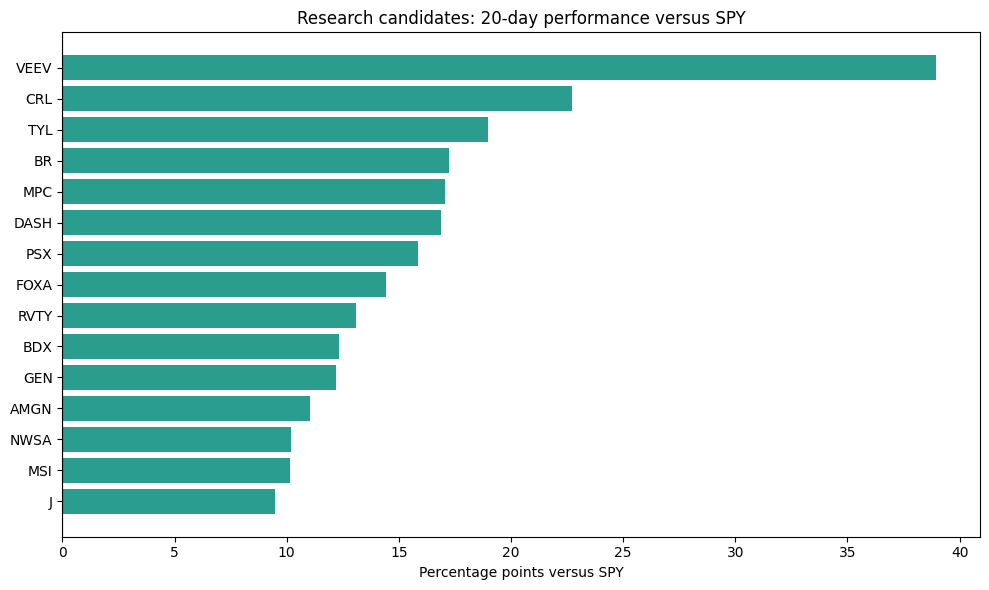

In [6]:
# Save the full screen, shortlist, and unavailable symbols to one Excel workbook.
with pd.ExcelWriter(OUTPUT_FILE, engine='xlsxwriter') as writer:
    screen.to_excel(writer, sheet_name='All Results', index=False)
    shortlist.to_excel(writer, sheet_name='Shortlist', index=False)
    early_accumulation_watch.to_excel(writer, sheet_name='Early Accumulation', index=False)
    pd.DataFrame({'Unavailable Symbol': missing_symbols}).to_excel(
        writer, sheet_name='Unavailable', index=False
    )
    pd.DataFrame([{
        'Run_UTC': RUN_TIMESTAMP_UTC,
        'Latest_SPY_Data_Date': spy_close.index[-1].strftime('%Y-%m-%d'),
        'Constituent_File': CONSTITUENTS_FILE,
        'History_Period': HISTORY_PERIOD,
    }]).to_excel(writer, sheet_name='Run Metadata', index=False)

    for sheet_name, dataframe in {
        'All Results': screen,
        'Shortlist': shortlist,
        'Early Accumulation': early_accumulation_watch,
    }.items():
        worksheet = writer.sheets[sheet_name]
        worksheet.freeze_panes(1, 0)
        worksheet.autofilter(0, 0, len(dataframe), len(dataframe.columns) - 1)
        for column_index, column in enumerate(dataframe.columns):
            worksheet.set_column(column_index, column_index, min(max(len(column) + 2, 14), 34))

print(f'Saved report: {OUTPUT_FILE}')

# A quick visual check: stocks with the best 20-day relative performance.
plot_data = shortlist.head(15).sort_values('Vs_SPY_20D_pp')
if not plot_data.empty:
    plt.figure(figsize=(10, 6))
    plt.barh(plot_data['Symbol'], plot_data['Vs_SPY_20D_pp'], color='#2a9d8f')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Research candidates: 20-day performance versus SPY')
    plt.xlabel('Percentage points versus SPY')
    plt.tight_layout()
    plt.show()
